# 4f Edge Detection — Learning the Vortex Phase Filter

We optimise a **phase-only** filter at the Fourier plane of a 4f system to
perform edge detection.  The filter is trained end-to-end over a dataset of
random binary scenes using gradient descent, with no prior knowledge of the
analytical solution.

The optimiser should independently discover the **spiral (vortex) phase
filter** $\phi(x, y) = \arg(x + iy)$, the well-known phase-only Fourier
filter for isotropic edge enhancement.

> **Prerequisites:** the [4f correlator notebook](4f_correlator_example.ipynb)
> covers the sampling-matched focal length and 4f geometry used here.

## 0  Imports


In [25]:
from __future__ import annotations

from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

from fouriax.example_utils import optimize_dataset_optical_module
from fouriax.optics import (
    ComplexMask,
    Field,
    Grid,
    IntensitySensor,
    OpticalModule,
    Spectrum,
    ThinLens,
)
from fouriax.optics.propagation import ASMPropagator
%matplotlib inline


## 1  Paths and Parameters

Artifact outputs are written under `artifacts/`, including the sampled training-scene
preview figure, optimization summary JSON, and final comparison plot.


In [26]:
ARTIFACTS_DIR = Path("artifacts")
PLOT_PATH = ARTIFACTS_DIR / "4f_edge_optimization.png"
SUMMARY_PATH = ARTIFACTS_DIR / "4f_edge_optimization_summary.json"

SEED = 0
WAVELENGTH_UM = 0.532
N_MEDIUM = 1.0
GRID_N = 128
GRID_DX_UM = 2.0
EPOCHS = 25
LR = 5e-3
N_TRAIN_SCENES = 1000
N_TEST_SCENES = 100


## 2 Helper Functions


In [27]:
def random_scene(key: jax.Array, grid: Grid) -> jnp.ndarray:
    noise = jax.random.normal(key, grid.shape)
    k = jnp.fft.fftn(noise, axes=(-2, -1))
    fx, fy = grid.frequency_grid()
    sigma_freq = 1.0 / (32.0 * grid.dx_um)
    lpf = jnp.exp(-(fx**2 + fy**2) / (2 * sigma_freq**2))
    smooth = jnp.real(jnp.fft.ifftn(k * lpf, axes=(-2, -1)))
    return (smooth > 0).astype(jnp.float32)


def edge_target(scene: jnp.ndarray) -> jnp.ndarray:
    padded = jnp.pad(scene, 1, mode="edge")
    gx = padded[1:-1, 2:] - padded[1:-1, :-2]
    gy = padded[2:, 1:-1] - padded[:-2, 1:-1]
    mag = jnp.sqrt(gx**2 + gy**2)
    return mag / jnp.maximum(jnp.max(mag), 1e-12)


def sampling_matched_f(grid: Grid) -> float:
    return N_MEDIUM * grid.nx * grid.dx_um**2 / WAVELENGTH_UM


def analytical_spiral_phase(grid: Grid) -> jnp.ndarray:
    x, y = grid.spatial_grid()
    return jnp.arctan2(y, x) + jnp.pi  # [0, 2π], centered on optical axis


def make_test_scene(grid: Grid) -> jnp.ndarray:
    x, y = grid.spatial_grid()
    half = grid.nx * grid.dx_um / 2.0
    scene = jnp.zeros(grid.shape, dtype=jnp.float32)
    scene = scene + ((jnp.abs(x - 0.2 * half) < 0.15 * half)
                      & (jnp.abs(y + 0.1 * half) < 0.15 * half)).astype(jnp.float32)
    scene = scene + ((jnp.abs(x + 0.3 * half) < 0.1 * half)
                      & (jnp.abs(y - 0.25 * half) < 0.1 * half)).astype(jnp.float32)
    r = jnp.sqrt((x + 0.1 * half) ** 2 + (y + 0.3 * half) ** 2)
    scene = scene + (r < 0.12 * half).astype(jnp.float32)
    return jnp.clip(scene, 0.0, 1.0)


def measure_scene(
    module: OpticalModule,
    scene: jnp.ndarray,
    grid: Grid,
    spectrum: Spectrum,
) -> jnp.ndarray:
    field_in = Field.plane_wave(grid=grid, spectrum=spectrum).apply_amplitude(
        scene[None, :, :],
    )
    return module.measure(field_in)[::-1, ::-1]


## 3  Training Data

Each training scene is generated by:

1. Drawing white noise on the simulation grid.
2. Low-pass filtering in $k$-space to produce smooth blobs.
3. Thresholding at zero to obtain a binary scene.

The smoothing scale controls feature size; larger values yield bigger
blobs with fewer, longer edges.  The corresponding edge targets are
computed via central finite differences (a discrete gradient magnitude).

In [28]:
grid = Grid.from_extent(nx=GRID_N, ny=GRID_N, dx_um=GRID_DX_UM, dy_um=GRID_DX_UM)
spectrum = Spectrum.from_scalar(WAVELENGTH_UM)
f_um = sampling_matched_f(grid)

prop = ASMPropagator(
    distance_um=f_um, use_sampling_planner=False, warn_on_regime_mismatch=False,
)
lens = ThinLens(focal_length_um=f_um)

def build_module(raw_phase: jnp.ndarray) -> OpticalModule:
    phase = 2.0 * jnp.pi * jax.nn.sigmoid(raw_phase)
    return OpticalModule(
        layers=(
            prop, lens, prop,
            ComplexMask(phase_map_rad=phase),
            prop, lens, prop,
        ),
        sensor=IntensitySensor(sum_wavelengths=True),
    )


## 4  Setup

The system follows the same geometry as the correlator notebook:

$$
\text{input}
\;\xrightarrow{\text{prop}(f)}\;
\text{Lens}_1
\;\xrightarrow{\text{prop}(f)}\;
\underbrace{e^{\,i\,\phi(x,y)}}_{\text{phase filter}}
\;\xrightarrow{\text{prop}(f)}\;
\text{Lens}_2
\;\xrightarrow{\text{prop}(f)}\;
\text{output}
$$

The phase $\phi$ is the **only trainable parameter**.  We parameterise it
as $\phi = 2\pi\,\sigma(\theta)$ where $\sigma$ is the sigmoid function
and $\theta$ is an unconstrained array optimised by Adam.

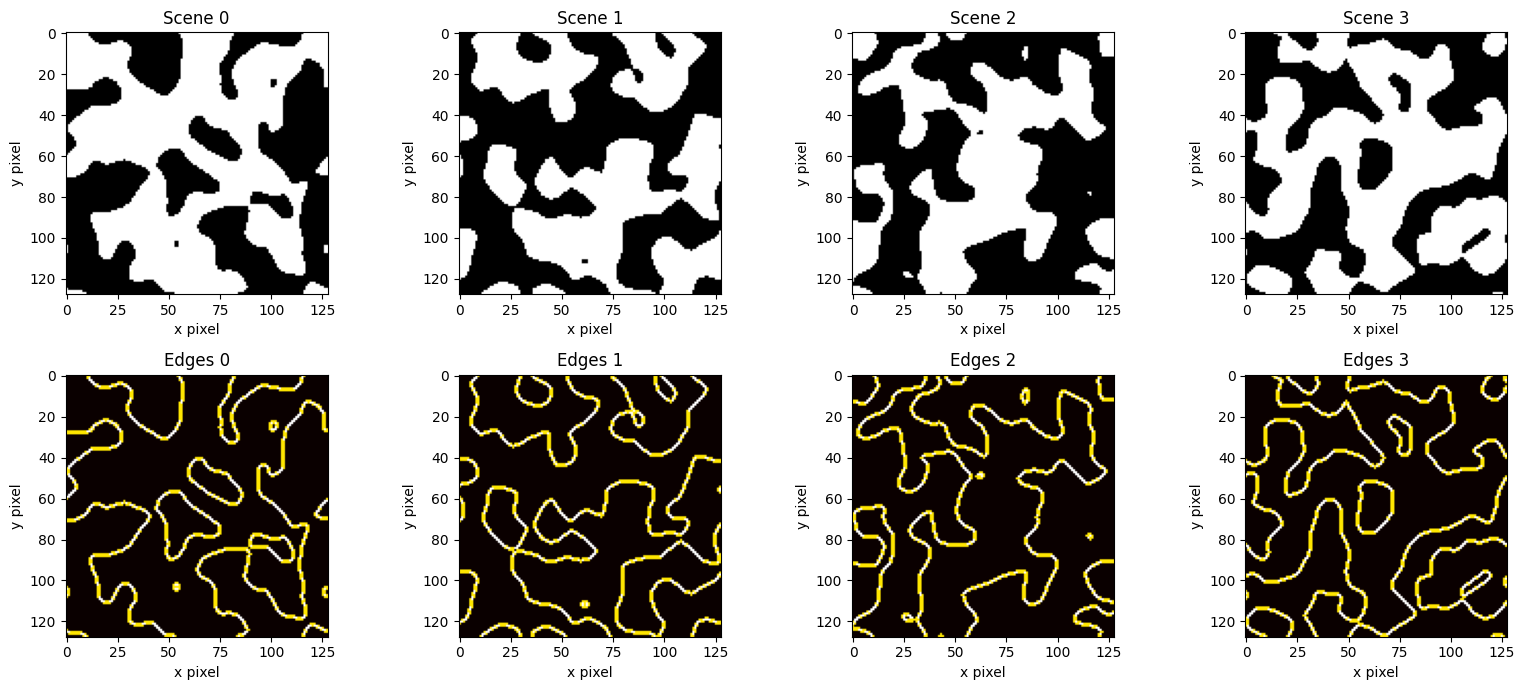

In [29]:
key = jax.random.PRNGKey(SEED)
key, *train_keys = jax.random.split(key, N_TRAIN_SCENES + 1)
train_scenes = jnp.stack([random_scene(k, grid) for k in train_keys])
train_targets = jnp.stack([edge_target(s) for s in train_scenes])
key, *test_keys = jax.random.split(key, N_TEST_SCENES + 1)
test_scenes = jnp.stack([random_scene(k, grid) for k in test_keys])
test_targets = jnp.stack([edge_target(s) for s in test_scenes])

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for col in range(4):
    axes[0, col].imshow(np.asarray(train_scenes[col]), cmap="gray")
    axes[0, col].set_title(f"Scene {col}")
    axes[1, col].imshow(np.asarray(train_targets[col]), cmap="hot")
    axes[1, col].set_title(f"Edges {col}")
for ax in axes.flat:
    ax.set_xlabel("x pixel")
    ax.set_ylabel("y pixel")
fig.tight_layout()
save_path = ARTIFACTS_DIR / "4f_edge_optimization_scenes.png"
fig.savefig(save_path)
plt.show()


## 5  Loss Function and Optimization

The loss is the mean squared error between the normalised 4f output
intensity and the target edge map.  Each gradient step uses one training
scene (SGD with batch size 1), cycling through the dataset.  Test loss
is evaluated every 50 steps on a held-out subset.

In [30]:
key, init_key = jax.random.split(key)
raw_phase = 0.1 * jax.random.normal(init_key, (grid.ny, grid.nx))
optimizer = optax.adam(LR)

n_test_eval = min(10, N_TEST_SCENES)  # evaluate on a subset for speed
val_data = (test_scenes[:n_test_eval], test_targets[:n_test_eval])

def loss_fn(
    params: jnp.ndarray,
    batch: tuple[jnp.ndarray, jnp.ndarray],
) -> jnp.ndarray:
    scenes, targets = batch
    scene = scenes[0]
    target = targets[0]
    module = build_module(params)
    out = measure_scene(module, scene, grid, spectrum)
    out_n = out / jnp.maximum(jnp.max(out), 1e-12)
    return jnp.mean((out_n - target) ** 2)

result = optimize_dataset_optical_module(
    init_params=raw_phase,
    build_module=build_module,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_data=(train_scenes, train_targets),
    batch_size=1,
    epochs=EPOCHS,
    val_data=val_data,
    seed=SEED,
)
train_history = result.params_result.train_loss_history
test_history = [
    (record.step, record.metrics["val_loss"]) for record in result.params_result.val_history
]


epoch=001 step=00999 train_loss=0.084430 val_loss=0.084226 [best]
epoch=002 step=01999 train_loss=0.078206 val_loss=0.083551 [best]
epoch=003 step=02999 train_loss=0.091963 val_loss=0.081620 [best]
epoch=004 step=03999 train_loss=0.073100 val_loss=0.076254 [best]
epoch=005 step=04999 train_loss=0.073602 val_loss=0.072578 [best]
epoch=006 step=05999 train_loss=0.070762 val_loss=0.071141 [best]
epoch=007 step=06999 train_loss=0.070286 val_loss=0.070530 [best]
epoch=008 step=07999 train_loss=0.074434 val_loss=0.070247 [best]
epoch=009 step=08999 train_loss=0.064633 val_loss=0.069426 [best]
epoch=010 step=09999 train_loss=0.070315 val_loss=0.069398 [best]
epoch=011 step=10999 train_loss=0.066732 val_loss=0.069137 [best]
epoch=012 step=11999 train_loss=0.061248 val_loss=0.069079 [best]
epoch=013 step=12999 train_loss=0.073998 val_loss=0.068992 [best]
epoch=014 step=13999 train_loss=0.065903 val_loss=0.068949 [best]
epoch=015 step=14999 train_loss=0.074039 val_loss=0.068827 [best]
epoch=016 

## 6 Evaluation


In [31]:
final_phase = np.asarray(2.0 * jnp.pi * jax.nn.sigmoid(result.params_result.best_params))
test_scene = make_test_scene(grid)
test_target = edge_target(test_scene)
test_out = np.asarray(measure_scene(result.best_module, test_scene, grid, spectrum))
test_out_n = test_out / np.max(test_out)
cc = float(np.corrcoef(test_out_n.ravel(), np.asarray(test_target).ravel())[0, 1])
print(f"Test-scene correlation: {cc:.4f}")

spiral = np.asarray(analytical_spiral_phase(grid))


Test-scene correlation: 0.7900


## 7  Plot Results

The known optimal phase-only Fourier filter for isotropic edge detection
is the vortex (spiral) phase:

$$
\phi_{\text{spiral}}(x, y) = \text{atan2}(y, x) + \pi
$$

where $(x, y)$ are centred coordinates in the Fourier plane (DC at the
optical axis).  We compare the optimised phase to this analytical
solution visually.

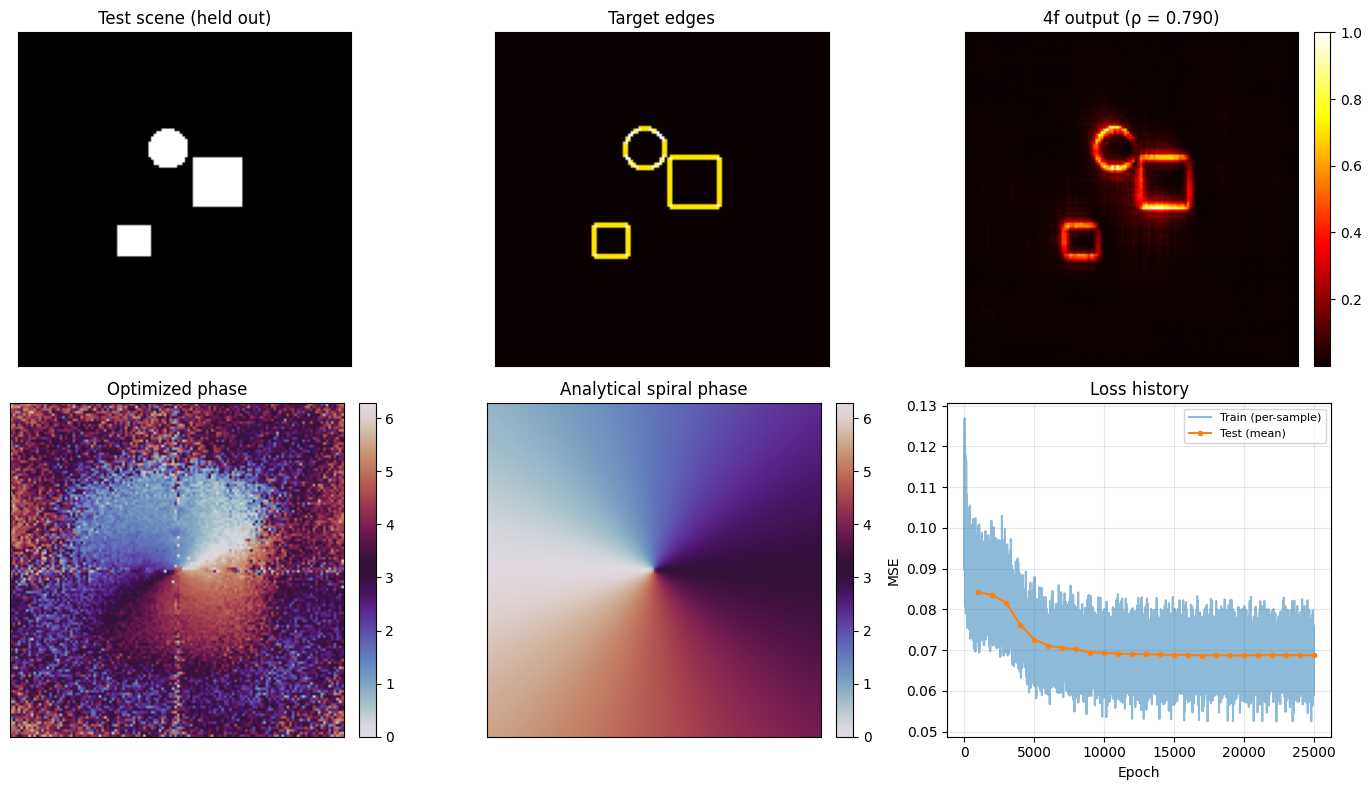

saved: artifacts/4f_edge_optimization.png


In [32]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].imshow(np.asarray(test_scene), cmap="gray")
axes[0, 0].set_title("Test scene (held out)")

axes[0, 1].imshow(np.asarray(test_target), cmap="hot")
axes[0, 1].set_title("Target edges")

im = axes[0, 2].imshow(test_out_n, cmap="hot")
axes[0, 2].set_title(f"4f output (ρ = {cc:.3f})")
fig.colorbar(im, ax=axes[0, 2], fraction=0.046, pad=0.04)

im_o = axes[1, 0].imshow(final_phase, cmap="twilight", vmin=0, vmax=2 * np.pi)
axes[1, 0].set_title("Optimized phase")
fig.colorbar(im_o, ax=axes[1, 0], fraction=0.046, pad=0.04)

im_s = axes[1, 1].imshow(spiral, cmap="twilight", vmin=0, vmax=2 * np.pi)
axes[1, 1].set_title("Analytical spiral phase")
fig.colorbar(im_s, ax=axes[1, 1], fraction=0.046, pad=0.04)

axes[1, 2].plot(train_history, alpha=0.5, label="Train (per-sample)")
test_steps, test_vals = zip(*test_history, strict=True)
axes[1, 2].plot(test_steps, test_vals, "o-", markersize=3, label="Test (mean)")
axes[1, 2].set_title("Loss history")
axes[1, 2].set_xlabel("Epoch")
axes[1, 2].set_ylabel("MSE")
axes[1, 2].legend(fontsize=8)
axes[1, 2].grid(alpha=0.3)

for ax in axes.flat:
    if ax.images:
        ax.set_xticks([])
        ax.set_yticks([])

fig.tight_layout()
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(PLOT_PATH, dpi=150)
plt.show()
print(f"saved: {PLOT_PATH}")
